## Naloga 4: Odprta naloga

V datoteki `dn3_cracked.csv` je podana podatkovna množica, kjer primeri ustrezajo študentom. Tvoja naloga je sestaviti napovedni model, ki glede na smiselno izbrano metriko čim bolje napove, ali je študent študij končal, ga še vedno opravlja, ali je s študijem prenehal (to so vrednosti v zadnjem stolpcu z naslovom `Target`).

Celoten postopek in vse poskuse (tudi neuspešne) zabeleži in o njih poročaj.

> Pozor: Ne predpostavljaj, da so podatki čisti. Izbira mere uspešnosti, postopek delitve podatkov in obravnava razredne neuravnoteženosti so del naloge — vse svoje odločitve dobro premisli in tudi pisno utemelji v oddani rešitvi.

Podatkovna množica vsebuje naslednje spremenljivke:

- Zakonski stan: kategorični
- Vrsta vloge: kategoričen
- Vrstni red vloge: int
- Tečaj: kategoričen
- Prisotnost podnevi/zvečer: kategorična
- Prejšnja kvalifikacija: kategorična
- Prejšnja kvalifikacija (ocena): float
- Državljanstvo: kategorialno
- Materina kvalifikacija: kategorična
- Očetova kvalifikacija: kategorična
- Poklic matere: kategoričen
- Poklic očeta: kategoričen
- Ocena pri vpisu: float
- Preseljen: kategorično
- Posebne izobraževalne potrebe: kategorično
- Dolžnik: kategorično
- Šolnine do datuma: kategorično
- Spol: kategorično
- Zadnje tri številke študentske izkaznice: int
- Štipendist: kategorično
- Starost ob vpisu: int
- Tujec: kategorično
- Učne enote 1. semester (priznane): int
- Učne enote 1. semester (vpisane): int
- Učne enote 1. semester (ocene): int
- Učne enote 1. semester (odobrene): int
- Učne enote 1. semester (ocena): float
- Učne enote 1. semester (brez ocen): int
- Učne enote 2. semester (priznane): int
- Učne enote 2. semester (vpisane): int
- Učne enote 2. semester (ocene): int
- Učne enote 2. semester (odobrene): int
- Učne enote 2. semester (ocena): float
- Učne enote 2. semester (brez ocen): int
- Stopnja brezposelnosti: float
- Stopnja inflacije: float
- BDP: float
- Standardiziran rezultat sprejemnega testa: float
- Indeks socioekonomskega statusa: float
- Anketni rezultat zadovoljstva: float
- Povprečna ocena srednje šole (normalizirana): float
- Indeks oddaljenosti od fakultete: float
- Mesečni dohodek staršev (z-score): float
- Rezultat psihološkega testa A: float
- Rezultat psihološkega testa B: float
- Indeks delovne obremenitve: float
- Število ur učenja na teden (z-score): float
- Indeks digitalne pismenosti: float
- Rezultat preverjanja angleščine: float
- Ocena motivacijskega pisma: float
- Indeks zdravstvenega stanja: float
- Rezultat testa logičnega sklepanja: float
- Številka prijave: int
- Šifra mentorja: int
- Številka razreda v srednji šoli: int
- Poštna številka: int
- Šifra študijskega programa: int
- Ciljna vrednost (`Target`): kategoričen


## 4.0 Cilj, čas napovedi in metrika

Nalogo obravnavamo kot neuravnoteženo večrazredno klasifikacijo (`Dropout`, `Enrolled`, `Graduate`). Primarna metrika je **macro-F1**, ker vse tri razrede obravnava enakovredno, čeprav je `Graduate` redek. Sekundarno poročamo balanced accuracy ter F1 in recall razreda `Graduate`.

Primarni model uporablja informacije do konca 2. semestra. Ločeno poročamo konservativno zgodnjo različico s podatki, ki so smiselno znani ob vpisu. Testno množico izločimo enkrat z `random_state=42` in `test_size=0.20`; do končne ocene je ne uporabljamo.

In [1]:
from pathlib import Path
import os
import platform
import time

os.environ.setdefault("LOKY_MAX_CPU_COUNT", "1")

import imblearn
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sklearn
from IPython.display import display

DATA_PATH = Path("dn3_cracked.csv")
TARGET_COLUMN = "Target"
RANDOM_STATE = 42

df = pd.read_csv(DATA_PATH, sep=";")

versions = pd.DataFrame({
    "Paket": ["Python", "NumPy", "pandas", "SciPy", "scikit-learn", "imbalanced-learn", "matplotlib"],
    "Različica": [
        platform.python_version(), np.__version__, pd.__version__, scipy.__version__,
        sklearn.__version__, imblearn.__version__, matplotlib.__version__,
    ],
})
display(versions)
print(f"Naloženo: {DATA_PATH.resolve()}")
print(f"Oblika podatkov: {df.shape[0]} vrstic × {df.shape[1]} stolpcev")

,Paket,Različica
0,Python,3.10.19
1,NumPy,2.2.6
2,pandas,2.3.3
3,SciPy,1.15.3
4,scikit-learn,1.7.2
5,imbalanced-learn,0.14.2
6,matplotlib,3.10.8


Naloženo: C:\Users\Brus\Documents\Faks\ITAP\dn3_cracked.csv
Oblika podatkov: 1875 vrstic × 58 stolpcev


## 4.1 Kratek audit podatkov

CSV beremo samo s pandas. Audit pokaže obseg manjkajočnosti, neuravnoteženost razredov, duplikate, osnovno veljavnost in identifikatorjem podobne stolpce. Dolge izpise vseh 58 stolpcev nadomestimo s povzetki in prikazom najbolj problematičnih stolpcev.

,Preverjanje,Rezultat
0,Oblika,"(1875, 58)"
1,Razredi Target,"{'Dropout': 1406, 'Enrolled': 375, 'Graduate':..."
2,Manjkajoče napovedne celice,8415 (7.87 %)
3,Napovedni stolpci z NaN,40 od 57
4,Popolne vrstice,18
5,Popolni duplikati,0
6,Duplikati po napovednih stolpcih,0
7,Neskončne vrednosti,0
8,Neveljavne binarne kode,0
9,Kršitve relacij učnih enot,0


Pandas tipi:


,Število stolpcev
float64,53
int64,4
object,1


Prve tri vrstice:


,Curricular units 2nd sem (enrolled),Scholarship holder,Curricular units 2nd sem (approved),Logical reasoning test score,Debtor,Mother's occupation,Mother's qualification,Application order,Digital literacy index,Admission grade,...,High school class number,Satisfaction survey score,Previous qualification,Age at enrollment,English proficiency test score,Postal code,Workload index,Educational special needs,Unemployment rate,Target
0,NaN,0.0,0.0,1.029202,0.0,4.0,1.0,2.0,0.497645,115.2,...,64857,-0.041278,1.0,21.0,-1.518980,16423,0.155148,1.0,15.5,Dropout
1,8.0,1.0,0.0,0.825069,NaN,9.0,19.0,1.0,-0.116446,125.8,...,79290,-1.053710,1.0,20.0,-0.536819,26941,0.386800,0.0,9.4,Enrolled
2,6.0,0.0,0.0,0.321814,0.0,9.0,19.0,2.0,2.255744,122.8,...,40883,-0.400564,NaN,19.0,1.384662,53610,0.499483,0.0,12.4,Dropout


Najbolj manjkajoči stolpci:


,Manjka,Delež (%)
Admission grade,225,12.00
Daytime/evening attendance,223,11.89
Curricular units 2nd sem (credited),222,11.84
Curricular units 2nd sem (enrolled),221,11.79
Curricular units 1st sem (grade),220,11.73
Curricular units 2nd sem (evaluations),219,11.68
Course,218,11.63
Gender,217,11.57
Application mode,216,11.52
Father's qualification,215,11.47


,Stolpec,Različne neprazne,Enoličnost / vse vrstice,Enoličnost / neprazne
0,Application number,1856,0.9899,0.9899
1,High school class number,1860,0.9920,0.9920
2,Postal code,1859,0.9915,0.9915
3,Study program code,1853,0.9883,0.9883
4,Mentor code,1673,0.8923,0.9911
5,Last three digits of the ID,100,0.0533,0.0592


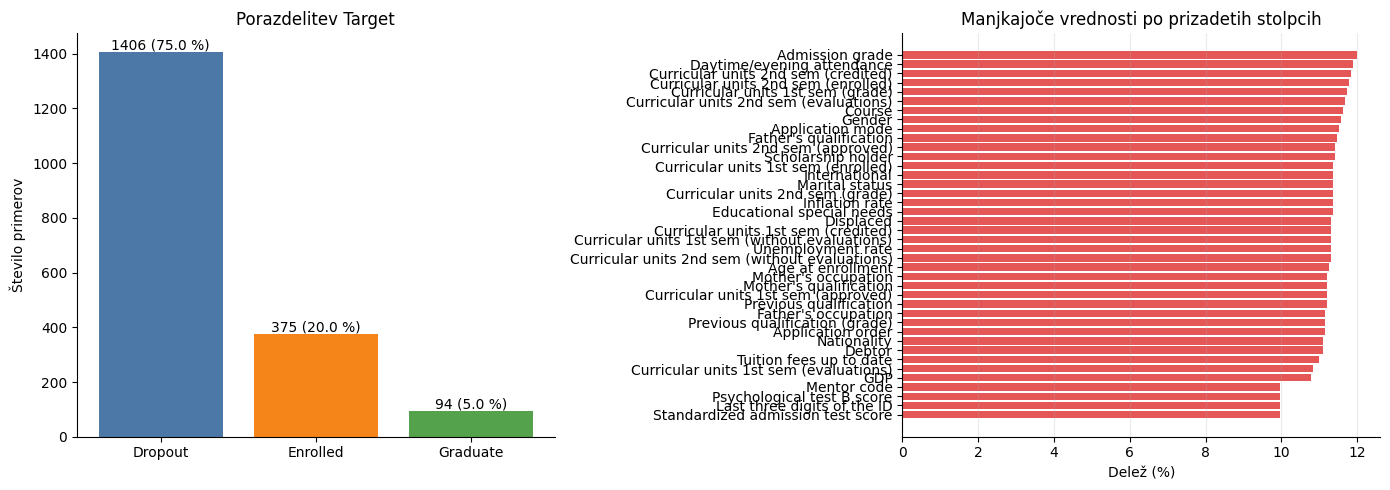

In [2]:
PREDICTOR_COLUMNS = [column for column in df.columns if column != TARGET_COLUMN]
CATEGORICAL_COLUMNS = [
    "Marital status", "Application mode", "Course", "Daytime/evening attendance",
    "Previous qualification", "Nationality", "Mother's qualification",
    "Father's qualification", "Mother's occupation", "Father's occupation",
    "Displaced", "Educational special needs", "Debtor", "Tuition fees up to date",
    "Gender", "Scholarship holder", "International",
]
ID_COLUMNS = [
    "Application number", "High school class number", "Postal code",
    "Study program code", "Mentor code", "Last three digits of the ID",
]
BASE_FEATURE_COLUMNS = [column for column in PREDICTOR_COLUMNS if column not in ID_COLUMNS]
NUMERIC_COLUMNS = [column for column in BASE_FEATURE_COLUMNS if column not in CATEGORICAL_COLUMNS]

SEMESTER_COLUMNS = [
    column for column in BASE_FEATURE_COLUMNS
    if column.startswith("Curricular units 1st sem")
    or column.startswith("Curricular units 2nd sem")
]
OTHER_POSSIBLY_POST_ENROLLMENT_COLUMNS = [
    "Satisfaction survey score", "Weekly study hours (z-score)", "Workload index",
]
EARLY_EXCLUDED_COLUMNS = SEMESTER_COLUMNS + OTHER_POSSIBLY_POST_ENROLLMENT_COLUMNS
EARLY_FEATURE_COLUMNS = [
    column for column in BASE_FEATURE_COLUMNS if column not in EARLY_EXCLUDED_COLUMNS
]

missing_by_column = df.isna().sum().sort_values(ascending=False)
affected_missing = missing_by_column.loc[missing_by_column > 0]
complete_rows = int(df[PREDICTOR_COLUMNS].notna().all(axis=1).sum())
target_counts = df[TARGET_COLUMN].value_counts().reindex(["Dropout", "Enrolled", "Graduate"])
numeric_values = df.select_dtypes(include="number").to_numpy()

binary_columns = [
    "Daytime/evening attendance", "Displaced", "Educational special needs", "Debtor",
    "Tuition fees up to date", "Gender", "Scholarship holder", "International",
]
binary_invalid = sum(
    int((~df[column].dropna().isin([0, 1])).sum()) for column in binary_columns
)
relation_violations = 0
for semester in ("1st", "2nd"):
    enrolled = df[f"Curricular units {semester} sem (enrolled)"]
    for kind in ("approved", "credited"):
        compared = df[f"Curricular units {semester} sem ({kind})"]
        relation_violations += int((compared > enrolled).fillna(False).sum())

audit_summary = pd.DataFrame({
    "Preverjanje": [
        "Oblika", "Razredi Target", "Manjkajoče napovedne celice",
        "Napovedni stolpci z NaN", "Popolne vrstice", "Popolni duplikati",
        "Duplikati po napovednih stolpcih", "Neskončne vrednosti",
        "Neveljavne binarne kode", "Kršitve relacij učnih enot",
    ],
    "Rezultat": [
        f"{df.shape}", target_counts.to_dict(),
        f"{int(df[PREDICTOR_COLUMNS].isna().sum().sum())} ({100 * df[PREDICTOR_COLUMNS].isna().sum().sum() / df[PREDICTOR_COLUMNS].size:.2f} %)",
        f"{len(affected_missing)} od {len(PREDICTOR_COLUMNS)}", complete_rows,
        int(df.duplicated().sum()), int(df.duplicated(subset=PREDICTOR_COLUMNS).sum()),
        int(np.isinf(numeric_values).sum()), binary_invalid, relation_violations,
    ],
})
display(audit_summary)

print("Pandas tipi:")
display(df.dtypes.astype(str).value_counts().rename("Število stolpcev").to_frame())
print("Prve tri vrstice:")
display(df.head(3))
print("Najbolj manjkajoči stolpci:")
display(pd.DataFrame({
    "Manjka": affected_missing.head(12),
    "Delež (%)": (100 * affected_missing.head(12) / len(df)).round(2),
}))

id_profile = pd.DataFrame({
    "Stolpec": ID_COLUMNS,
    "Različne neprazne": [df[column].nunique(dropna=True) for column in ID_COLUMNS],
    "Enoličnost / vse vrstice": [df[column].nunique(dropna=True) / len(df) for column in ID_COLUMNS],
    "Enoličnost / neprazne": [
        df[column].nunique(dropna=True) / df[column].notna().sum() for column in ID_COLUMNS
    ],
})
display(id_profile.style.format({
    "Enoličnost / vse vrstice": "{:.4f}",
    "Enoličnost / neprazne": "{:.4f}",
}))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bars = axes[0].bar(target_counts.index, target_counts.values, color=["#4C78A8", "#F58518", "#54A24B"])
axes[0].bar_label(bars, labels=[f"{count} ({100 * count / len(df):.1f} %)" for count in target_counts])
axes[0].set(title="Porazdelitev Target", ylabel="Število primerov")
axes[0].spines[["top", "right"]].set_visible(False)

missing_share = (100 * affected_missing / len(df)).sort_values()
axes[1].barh(missing_share.index, missing_share.values, color="#E45756")
axes[1].set(title="Manjkajoče vrednosti po prizadetih stolpcih", xlabel="Delež (%)", ylabel="")
axes[1].grid(axis="x", alpha=0.25)
axes[1].spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

assert df.shape == (1875, 58)
assert target_counts.to_dict() == {"Dropout": 1406, "Enrolled": 375, "Graduate": 94}
assert int(df[PREDICTOR_COLUMNS].isna().sum().sum()) == 8415
assert len(affected_missing) == 40 and complete_rows == 18
assert df.duplicated().sum() == 0 and df.duplicated(subset=PREDICTOR_COLUMNS).sum() == 0
assert np.isinf(numeric_values).sum() == 0 and binary_invalid == 0 and relation_violations == 0
assert len(CATEGORICAL_COLUMNS) == 17 and len(ID_COLUMNS) == 6
assert len(BASE_FEATURE_COLUMNS) == 51 and len(NUMERIC_COLUMNS) == 34
assert len(SEMESTER_COLUMNS) == 12 and len(EARLY_FEATURE_COLUMNS) == 36

### Odločitve po auditu

- `Target` je močno neuravnotežen: 74,99 % `Dropout`, 20,00 % `Enrolled` in 5,01 % `Graduate`; zato accuracy ni primerna glavna metrika.
- Manjka 8.415 napovednih vrednosti (7,87 %). Samo 18 vrstic je popolnih, zato vrstic ne brišemo; imputacija bo vedno znotraj pipelinea.
- Duplikatov, neskončnosti, neveljavnih binarnih kod in očitnih kršitev relacij ni. Redkih kategoričnih kod brez uradnega šifranta ne razglasimo za napake.
- Šest ID-stolpcev izločimo iz osnovnega modela. `Course` ostane med 17 vsebinskimi kategorijami. Pozneje vpliv ID-stolpcev preverimo z ablacijo.
- Polna različica vsebuje 51 značilk; konservativna zgodnja različica jih vsebuje 36.

## 4.2 Pošten eksperimentalni protokol

Test izločimo pred učenjem. Vse imputacije, kodiranje, skaliranje, razredne uteži in SMOTENC se učijo samo znotraj učnih foldov. Izbira modela uporablja petkratni stratificirani CV na 1.500 učnih primerih.

In [3]:
from sklearn.model_selection import StratifiedKFold, train_test_split

X = df[BASE_FEATURE_COLUMNS].copy()
y = df[TARGET_COLUMN].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

CV_SPLITTER = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
train_counts = y_train.value_counts().reindex(["Dropout", "Enrolled", "Graduate"])

print(f"Učni del: {len(X_train)} primerov, {X_train.shape[1]} značilk")
display(train_counts.rename("Število").to_frame())
print(f"Izolirani test: {len(df) - len(X_train)} primerov; do končne ocene ga ne pregledujemo.")

for _, validation_indices in CV_SPLITTER.split(X_train, y_train):
    fold_counts = y_train.iloc[validation_indices].value_counts()
    assert fold_counts.to_dict() == {"Dropout": 225, "Enrolled": 60, "Graduate": 15}

assert X_train.shape == (1500, 51)
assert train_counts.to_dict() == {"Dropout": 1125, "Enrolled": 300, "Graduate": 75}
assert set(ID_COLUMNS).isdisjoint(X_train.columns)

Učni del: 1500 primerov, 51 značilk


,Število
Target,
Dropout,1125
Enrolled,300
Graduate,75


Izolirani test: 375 primerov; do končne ocene ga ne pregledujemo.


### Predprocesiranje in metrike

Kategorične vrednosti imputiramo z modusom in kodiramo z `OneHotEncoder(handle_unknown='ignore')`. Numerične vrednosti imputiramo z mediano, dodamo indikatorje manjkajočnosti in standardiziramo. Funkcija spodaj ima en parameter `dense_output`; gost izhod uporabimo samo pri HistGradientBoosting.

In [4]:
from scipy import sparse
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import f1_score, make_scorer, recall_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

CLASS_ORDER = ["Dropout", "Enrolled", "Graduate"]

def one_class_scorer(metric, target_class):
    return make_scorer(
        metric, labels=[target_class], average="macro", zero_division=0
    )

SELECTION_SCORING = {
    "macro_f1": "f1_macro",
    "balanced_accuracy": "balanced_accuracy",
    "graduate_f1": one_class_scorer(f1_score, "Graduate"),
    "graduate_recall": one_class_scorer(recall_score, "Graduate"),
}
INITIAL_SCORING = dict(SELECTION_SCORING)
for target_class in ("Dropout", "Enrolled"):
    key = target_class.lower()
    INITIAL_SCORING[f"{key}_f1"] = one_class_scorer(f1_score, target_class)
    INITIAL_SCORING[f"{key}_recall"] = one_class_scorer(recall_score, target_class)

def build_model_pipeline(estimator, feature_columns=BASE_FEATURE_COLUMNS, dense_output=False):
    categorical = [column for column in CATEGORICAL_COLUMNS if column in feature_columns]
    numeric = [column for column in feature_columns if column not in categorical]

    preprocessor = ColumnTransformer(
        transformers=[
            ("categorical", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(
                    handle_unknown="ignore", sparse_output=not dense_output
                )),
            ]), categorical),
            ("numeric", Pipeline([
                ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
                ("scaler", StandardScaler()),
            ]), numeric),
        ],
        remainder="drop",
        sparse_threshold=0.0 if dense_output else 0.3,
        verbose_feature_names_out=True,
    )
    return Pipeline([
        ("preprocessor", preprocessor),
        ("model", estimator),
    ])

# Diagnostika je prileganje celotnega pipelinea samo na učnem delu.
diagnostic_pipeline = build_model_pipeline(DummyClassifier(strategy="most_frequent"))
diagnostic_pipeline.fit(X_train, y_train)
transformed_train = diagnostic_pipeline.named_steps["preprocessor"].transform(X_train)
transformed_values = transformed_train.data if sparse.issparse(transformed_train) else np.asarray(transformed_train)
feature_names = diagnostic_pipeline.named_steps["preprocessor"].get_feature_names_out()

print(f"Predprocesiran učni del: {transformed_train.shape}")
print(f"Končne vrednosti: {np.isfinite(transformed_values).all()}")
assert transformed_train.shape == (1500, 237)
assert len(feature_names) == 237 and np.isfinite(transformed_values).all()

Predprocesiran učni del: (1500, 237)
Končne vrednosti: True


## 4.3 Začetni modeli in neuravnoteženost

Na istih foldih primerjamo dummy modela, logistično regresijo, Extra Trees, HistGradientBoosting ter SMOTENC. Navadnega SMOTE po one-hot kodiranju ne uporabimo, ker bi ustvaril delne kategorije.

E00: macro-F1=0.286 ± 0.000


E00S: macro-F1=0.352 ± 0.029


E01: macro-F1=0.548 ± 0.031


E02: macro-F1=0.550 ± 0.014


E03: macro-F1=0.384 ± 0.022


E04: macro-F1=0.510 ± 0.022


E05: macro-F1=0.488 ± 0.042


E06: macro-F1=0.533 ± 0.049


E07: macro-F1=0.541 ± 0.028


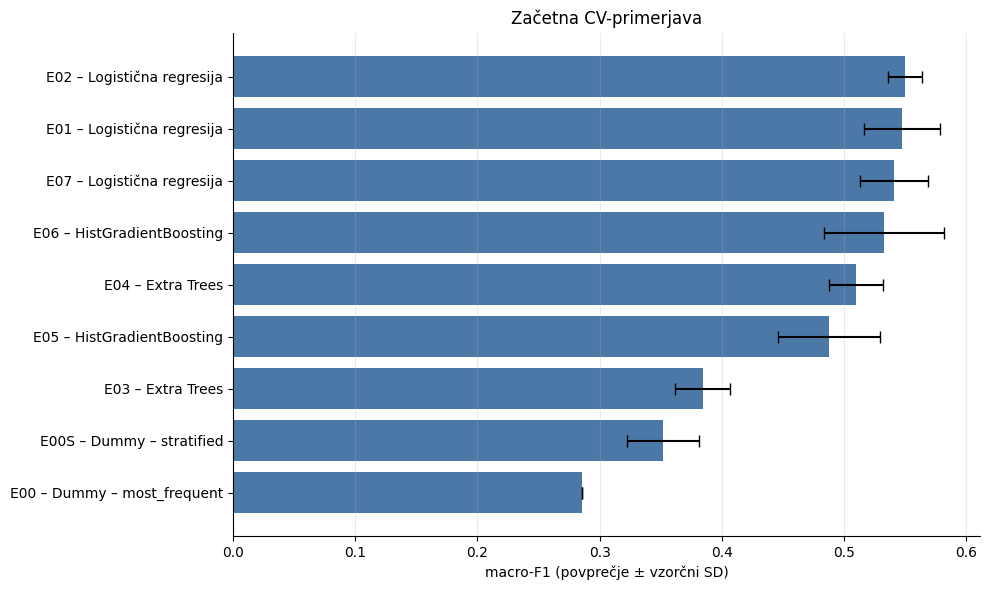

In [5]:
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.impute import MissingIndicator
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate
from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline

def build_smotenc_logistic_pipeline():
    numeric_indicators = [f"missingindicator_{column}" for column in NUMERIC_COLUMNS]
    smotenc_categorical = CATEGORICAL_COLUMNS + numeric_indicators

    pre_imputation = ColumnTransformer(
        transformers=[
            ("categorical", SimpleImputer(strategy="most_frequent"), CATEGORICAL_COLUMNS),
            ("numeric", SimpleImputer(strategy="median"), NUMERIC_COLUMNS),
            ("missing", MissingIndicator(features="all"), NUMERIC_COLUMNS),
        ],
        verbose_feature_names_out=False,
    ).set_output(transform="pandas")
    post_resampling = ColumnTransformer(
        transformers=[
            ("categorical", OneHotEncoder(handle_unknown="ignore"), smotenc_categorical),
            ("numeric", StandardScaler(), NUMERIC_COLUMNS),
        ],
        remainder="drop",
    )
    return ImbPipeline([
        ("pre_imputation", pre_imputation),
        ("smotenc", SMOTENC(
            categorical_features=smotenc_categorical,
            sampling_strategy="not majority",
            k_neighbors=5,
            random_state=RANDOM_STATE,
        )),
        ("post_resampling", post_resampling),
        ("model", LogisticRegression(
            C=1.0, max_iter=3000, solver="lbfgs", random_state=RANDOM_STATE
        )),
    ])

EXPERIMENT_SPECS = [
    {"ID": "E00", "Model": "Dummy – most_frequent", "Balance": "brez",
     "Pipeline": build_model_pipeline(DummyClassifier(strategy="most_frequent"))},
    {"ID": "E00S", "Model": "Dummy – stratified", "Balance": "brez",
     "Pipeline": build_model_pipeline(DummyClassifier(strategy="stratified", random_state=RANDOM_STATE))},
    {"ID": "E01", "Model": "Logistična regresija", "Balance": "brez",
     "Pipeline": build_model_pipeline(LogisticRegression(
         C=1.0, max_iter=3000, solver="lbfgs", random_state=RANDOM_STATE
     ))},
    {"ID": "E02", "Model": "Logistična regresija", "Balance": "class_weight=balanced",
     "Pipeline": build_model_pipeline(LogisticRegression(
         C=1.0, max_iter=3000, solver="lbfgs", class_weight="balanced",
         random_state=RANDOM_STATE
     ))},
    {"ID": "E03", "Model": "Extra Trees", "Balance": "brez",
     "Pipeline": build_model_pipeline(ExtraTreesClassifier(
         n_estimators=400, min_samples_leaf=2, max_features="sqrt",
         n_jobs=1, random_state=RANDOM_STATE
     ))},
    {"ID": "E04", "Model": "Extra Trees", "Balance": "class_weight=balanced",
     "Pipeline": build_model_pipeline(ExtraTreesClassifier(
         n_estimators=400, min_samples_leaf=2, max_features="sqrt",
         class_weight="balanced", n_jobs=1, random_state=RANDOM_STATE
     ))},
    {"ID": "E05", "Model": "HistGradientBoosting", "Balance": "brez",
     "Pipeline": build_model_pipeline(HistGradientBoostingClassifier(
         learning_rate=0.05, max_iter=200, max_leaf_nodes=15, min_samples_leaf=20,
         random_state=RANDOM_STATE
     ), dense_output=True)},
    {"ID": "E06", "Model": "HistGradientBoosting", "Balance": "class_weight=balanced",
     "Pipeline": build_model_pipeline(HistGradientBoostingClassifier(
         learning_rate=0.05, max_iter=200, max_leaf_nodes=15, min_samples_leaf=20,
         class_weight="balanced", random_state=RANDOM_STATE
     ), dense_output=True)},
    {"ID": "E07", "Model": "Logistična regresija", "Balance": "SMOTENC",
     "Pipeline": build_smotenc_logistic_pipeline()},
]

initial_rows = []
for spec in EXPERIMENT_SPECS:
    started = time.perf_counter()
    try:
        scores = cross_validate(
            spec["Pipeline"], X_train, y_train, cv=CV_SPLITTER,
            scoring=INITIAL_SCORING, n_jobs=1, error_score="raise",
        )
        row = {
            "ID": spec["ID"], "Model": spec["Model"], "Balance": spec["Balance"],
            "Status": "uspešno", "Čas (s)": time.perf_counter() - started,
        }
        for metric in INITIAL_SCORING:
            values = scores[f"test_{metric}"]
            row[f"{metric}_mean"] = float(np.mean(values))
            row[f"{metric}_std"] = float(np.std(values, ddof=1))
        initial_rows.append(row)
        print(f"{spec['ID']}: macro-F1={row['macro_f1_mean']:.3f} ± {row['macro_f1_std']:.3f}")
    except Exception as error:
        initial_rows.append({
            "ID": spec["ID"], "Model": spec["Model"], "Balance": spec["Balance"],
            "Status": "napaka", "Čas (s)": time.perf_counter() - started,
            "Napaka": f"{type(error).__name__}: {error}",
        })
        print(f"{spec['ID']}: NAPAKA – {type(error).__name__}: {error}")

initial_summary = pd.DataFrame(initial_rows)
successful_initial = initial_summary.loc[initial_summary["Status"] == "uspešno"].copy()
assert len(successful_initial) == len(EXPERIMENT_SPECS)

plot_data = successful_initial.sort_values("macro_f1_mean")
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    plot_data["ID"] + " – " + plot_data["Model"],
    plot_data["macro_f1_mean"],
    xerr=plot_data["macro_f1_std"],
    color="#4C78A8", capsize=4,
)
ax.set(title="Začetna CV-primerjava", xlabel="macro-F1 (povprečje ± vzorčni SD)", ylabel="")
ax.grid(axis="x", alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 4.4 Uglaševanje in izbor

Uglašujemo najboljšo linearno družino in najboljši nelinearni kandidat. `RandomizedSearchCV` hkrati izračuna macro-F1, balanced accuracy, Graduate F1 in Graduate recall ter ponovno prilega nastavitev z najboljšim `macro_f1`. Selekcijske ocene izbrane nastavitve preberemo neposredno iz `cv_results_`; istih foldov ne ocenjujemo še enkrat.

In [6]:
from scipy.stats import loguniform, randint
from sklearn.model_selection import RandomizedSearchCV

TUNING_ITERATIONS = 20
TUNING_SPECS = [
    {
        "ID": "T01", "Model": "Logistična regresija",
        "Estimator": build_model_pipeline(LogisticRegression(
            max_iter=4000, solver="lbfgs", random_state=RANDOM_STATE
        )),
        "Parametri": {
            "model__C": loguniform(1e-3, 1e2),
            "model__class_weight": [None, "balanced"],
        },
    },
    {
        "ID": "T02", "Model": "HistGradientBoosting",
        "Estimator": build_model_pipeline(HistGradientBoostingClassifier(
            early_stopping=True, validation_fraction=0.15, n_iter_no_change=15,
            random_state=RANDOM_STATE
        ), dense_output=True),
        "Parametri": {
            "model__learning_rate": loguniform(0.02, 0.20),
            "model__max_iter": randint(100, 301),
            "model__max_leaf_nodes": randint(7, 64),
            "model__min_samples_leaf": randint(10, 61),
            "model__l2_regularization": loguniform(1e-4, 10.0),
            "model__class_weight": [None, "balanced"],
        },
    },
]

def native_value(value):
    return value.item() if isinstance(value, np.generic) else value

tuning_searches = {}
tuning_rows = []
for spec in TUNING_SPECS:
    print(f"Začenjam {spec['ID']}: {spec['Model']} ...")
    started = time.perf_counter()
    try:
        search = RandomizedSearchCV(
            estimator=spec["Estimator"],
            param_distributions=spec["Parametri"],
            n_iter=TUNING_ITERATIONS,
            scoring=SELECTION_SCORING,
            refit="macro_f1",
            cv=CV_SPLITTER,
            random_state=RANDOM_STATE,
            n_jobs=1,
            error_score="raise",
            return_train_score=False,
        )
        search.fit(X_train, y_train)
        elapsed = time.perf_counter() - started
        tuning_searches[spec["ID"]] = search
        best_index = search.best_index_
        cv_results = search.cv_results_
        best_params = {key: native_value(value) for key, value in search.best_params_.items()}
        row = {
            "ID": spec["ID"], "Model": spec["Model"], "Status": "uspešno",
            "Kombinacije": TUNING_ITERATIONS, "Čas (s)": elapsed,
            "Najboljši parametri": best_params,
            "selection_macro_f1_mean": float(cv_results["mean_test_macro_f1"][best_index]),
            "selection_macro_f1_std": float(cv_results["std_test_macro_f1"][best_index]),
            "selection_balanced_accuracy_mean": float(cv_results["mean_test_balanced_accuracy"][best_index]),
            "selection_graduate_f1_mean": float(cv_results["mean_test_graduate_f1"][best_index]),
            "selection_graduate_recall_mean": float(cv_results["mean_test_graduate_recall"][best_index]),
        }
        tuning_rows.append(row)
        print(
            f"{spec['ID']}: selekcijski macro-F1={row['selection_macro_f1_mean']:.3f} "
            f"± {row['selection_macro_f1_std']:.3f}"
        )
    except Exception as error:
        tuning_rows.append({
            "ID": spec["ID"], "Model": spec["Model"], "Status": "napaka",
            "Kombinacije": TUNING_ITERATIONS, "Čas (s)": time.perf_counter() - started,
            "Napaka": f"{type(error).__name__}: {error}",
        })
        print(f"{spec['ID']}: NAPAKA – {type(error).__name__}: {error}")

tuning_summary = pd.DataFrame(tuning_rows)
successful_tuning = tuning_summary.loc[tuning_summary["Status"] == "uspešno"].copy()
assert len(successful_tuning) == 2

macro_gap = float(
    successful_tuning["selection_macro_f1_mean"].max()
    - successful_tuning["selection_macro_f1_mean"].min()
)
if macro_gap <= 0.01:
    finalist_row = successful_tuning.sort_values(
        ["selection_macro_f1_std", "selection_balanced_accuracy_mean", "selection_graduate_f1_mean"],
        ascending=[True, False, False],
    ).iloc[0]
    finalist_reason = "macro-F1 je znotraj 0,01; odločili so manjši raztros in sekundarne metrike"
else:
    finalist_row = successful_tuning.sort_values("selection_macro_f1_mean", ascending=False).iloc[0]
    finalist_reason = "izbrano je najvišje selekcijsko CV-povprečje macro-F1"

FINALIST_ID = finalist_row["ID"]
FINALIST_SEARCH = tuning_searches[FINALIST_ID]
FINALIST_PIPELINE = FINALIST_SEARCH.best_estimator_

for _, row in successful_tuning.sort_values("selection_macro_f1_mean", ascending=False).iterrows():
    print(
        f"{row['ID']} {row['Model']}: macro-F1={row['selection_macro_f1_mean']:.3f} "
        f"± {row['selection_macro_f1_std']:.3f}, balanced accuracy="
        f"{row['selection_balanced_accuracy_mean']:.3f}, Graduate F1="
        f"{row['selection_graduate_f1_mean']:.3f}, Graduate recall="
        f"{row['selection_graduate_recall_mean']:.3f}"
    )
print(f"Finalist: {FINALIST_ID} – {finalist_row['Model']}; {finalist_reason}.")
print("Zaklenjeni test še ni bil uporabljen.")

Začenjam T01: Logistična regresija ...


T01: selekcijski macro-F1=0.558 ± 0.029
Začenjam T02: HistGradientBoosting ...


T02: selekcijski macro-F1=0.558 ± 0.011
T01 Logistična regresija: macro-F1=0.558 ± 0.029, balanced accuracy=0.548, Graduate F1=0.321, Graduate recall=0.307
T02 HistGradientBoosting: macro-F1=0.558 ± 0.011, balanced accuracy=0.635, Graduate F1=0.342, Graduate recall=0.547
Finalist: T02 – HistGradientBoosting; macro-F1 je znotraj 0,01; odločili so manjši raztros in sekundarne metrike.
Zaklenjeni test še ni bil uporabljen.


## 4.5 Ablaciji in enotna sled poskusov

Z že izbranimi parametri T02 na učnem CV preverimo zgodnjo različico in dodatek ID-stolpcev. Ablaciji sta vsebinski kontroli in ne spreminjata finalista.

In [7]:
selected_model_template = clone(FINALIST_PIPELINE.named_steps["model"])
ALL_PREDICTOR_COLUMNS = list(PREDICTOR_COLUMNS)
ablation_specs = [
    {
        "ID": "A01", "Različica": "Zgodnja ob vpisu", "Features": EARLY_FEATURE_COLUMNS,
        "Pipeline": build_model_pipeline(
            clone(selected_model_template), EARLY_FEATURE_COLUMNS, dense_output=True
        ),
    },
    {
        "ID": "A02", "Različica": "Polna + 6 ID-stolpcev", "Features": ALL_PREDICTOR_COLUMNS,
        "Pipeline": build_model_pipeline(
            clone(selected_model_template), ALL_PREDICTOR_COLUMNS, dense_output=True
        ),
    },
]

ablation_rows = []
for spec in ablation_specs:
    started = time.perf_counter()
    try:
        scores = cross_validate(
            spec["Pipeline"],
            df.loc[X_train.index, spec["Features"]],
            y_train,
            cv=CV_SPLITTER,
            scoring=SELECTION_SCORING,
            n_jobs=1,
            error_score="raise",
        )
        ablation_rows.append({
            "ID": spec["ID"], "Različica": spec["Različica"],
            "Status": "uspešno", "Značilke": len(spec["Features"]),
            "Čas (s)": time.perf_counter() - started,
            "macro_f1_mean": float(np.mean(scores["test_macro_f1"])),
            "macro_f1_std": float(np.std(scores["test_macro_f1"], ddof=1)),
            "balanced_accuracy_mean": float(np.mean(scores["test_balanced_accuracy"])),
            "graduate_f1_mean": float(np.mean(scores["test_graduate_f1"])),
            "graduate_recall_mean": float(np.mean(scores["test_graduate_recall"])),
        })
    except Exception as error:
        ablation_rows.append({
            "ID": spec["ID"], "Različica": spec["Različica"],
            "Status": "napaka", "Značilke": len(spec["Features"]),
            "Čas (s)": time.perf_counter() - started,
            "Napaka": f"{type(error).__name__}: {error}",
        })

ablation_summary = pd.DataFrame(ablation_rows)
assert (ablation_summary["Status"] == "uspešno").all()

experiment_log_rows = []
for _, row in initial_summary.iterrows():
    experiment_log_rows.append({
        "ID": row["ID"], "Vrsta": "začetni CV", "Model / podatki": row["Model"],
        "Uravnoteženje / opomba": row["Balance"],
        "CV macro-F1": f"{row['macro_f1_mean']:.3f} ± {row['macro_f1_std']:.3f}" if row["Status"] == "uspešno" else "—",
        "Graduate F1": f"{row['graduate_f1_mean']:.3f}" if row["Status"] == "uspešno" else "—",
        "Status / odločitev": row["Status"],
    })
for _, row in tuning_summary.iterrows():
    experiment_log_rows.append({
        "ID": row["ID"], "Vrsta": "RandomizedSearchCV", "Model / podatki": row["Model"],
        "Uravnoteženje / opomba": "20 kombinacij; selekcijske CV-ocene",
        "CV macro-F1": f"{row['selection_macro_f1_mean']:.3f} ± {row['selection_macro_f1_std']:.3f}" if row["Status"] == "uspešno" else "—",
        "Graduate F1": f"{row['selection_graduate_f1_mean']:.3f}" if row["Status"] == "uspešno" else "—",
        "Status / odločitev": "finalist" if row["ID"] == FINALIST_ID else "ni izbran",
    })
for _, row in ablation_summary.iterrows():
    experiment_log_rows.append({
        "ID": row["ID"], "Vrsta": "ablacijski CV", "Model / podatki": row["Različica"],
        "Uravnoteženje / opomba": "parametri T02",
        "CV macro-F1": f"{row['macro_f1_mean']:.3f} ± {row['macro_f1_std']:.3f}",
        "Graduate F1": f"{row['graduate_f1_mean']:.3f}",
        "Status / odločitev": "vsebinska kontrola; finalist ostane nespremenjen",
    })

experiment_log = pd.DataFrame(experiment_log_rows)
display(experiment_log)
print(f"Sled vsebuje {len(experiment_log)} poskusov oziroma kontrol.")

early_row = ablation_summary.loc[ablation_summary["ID"] == "A01"].iloc[0]
id_row = ablation_summary.loc[ablation_summary["ID"] == "A02"].iloc[0]
print(f"Zgodnja različica: macro-F1={early_row['macro_f1_mean']:.3f} ± {early_row['macro_f1_std']:.3f}")
print(f"Polna + ID: macro-F1={id_row['macro_f1_mean']:.3f} ± {id_row['macro_f1_std']:.3f}")

,ID,Vrsta,Model / podatki,Uravnoteženje / opomba,CV macro-F1,Graduate F1,Status / odločitev
0,E00,začetni CV,Dummy – most_frequent,brez,0.286 ± 0.000,0.000,uspešno
1,E00S,začetni CV,Dummy – stratified,brez,0.352 ± 0.029,0.073,uspešno
2,E01,začetni CV,Logistična regresija,brez,0.548 ± 0.031,0.297,uspešno
3,E02,začetni CV,Logistična regresija,class_weight=balanced,0.550 ± 0.014,0.327,uspešno
4,E03,začetni CV,Extra Trees,brez,0.384 ± 0.022,0.000,uspešno
5,E04,začetni CV,Extra Trees,class_weight=balanced,0.510 ± 0.022,0.158,uspešno
6,E05,začetni CV,HistGradientBoosting,brez,0.488 ± 0.042,0.179,uspešno
7,E06,začetni CV,HistGradientBoosting,class_weight=balanced,0.533 ± 0.049,0.242,uspešno
8,E07,začetni CV,Logistična regresija,SMOTENC,0.541 ± 0.028,0.315,uspešno
9,T01,RandomizedSearchCV,Logistična regresija,20 kombinacij; selekcijske CV-ocene,0.558 ± 0.029,0.321,ni izbran


Sled vsebuje 13 poskusov oziroma kontrol.
Zgodnja različica: macro-F1=0.408 ± 0.007
Polna + ID: macro-F1=0.570 ± 0.028


### Izbor pred testom

Začetni poskusi pokažejo, da razredne uteži pomagajo drevesnim modelom, SMOTENC pa ne preseže najboljših uglašenih kandidatov. Uglašena logistična regresija T01 doseže selekcijski CV macro-F1 **0,558 ± 0,029**, HistGradientBoosting T02 pa **0,558 ± 0,011**. Zaradi manjšega raztrosa in boljših sekundarnih metrik je finalist T02. Zgodnji model je bistveno slabši, rahlo izboljšanje z ID-stolpci pa zaradi tveganja uhajanja zavrnemo.

## 4.6 Enkratna končna testna ocena

`X_test` in `y_test` se spodaj prvič uporabita po razdelitvi. Model in hiperparametri so že zaklenjeni. Po tej oceni jih ne spreminjamo več.

,Metrika,Vrednost
0,Accuracy,0.685
1,Balanced accuracy,0.556
2,Macro-F1,0.528


,Razred,Precision,Recall,F1,Support
0,Dropout,0.878,0.740,0.803,281
1,Enrolled,0.362,0.560,0.440,75
2,Graduate,0.318,0.368,0.341,19


,Napovedani Dropout,Napovedani Enrolled,Napovedani Graduate
Dejanski Dropout,208,63,10
Dejanski Enrolled,28,42,5
Dejanski Graduate,1,11,7


Testni macro-F1=0.528; 95-% bootstrap interval=[0.451, 0.601]


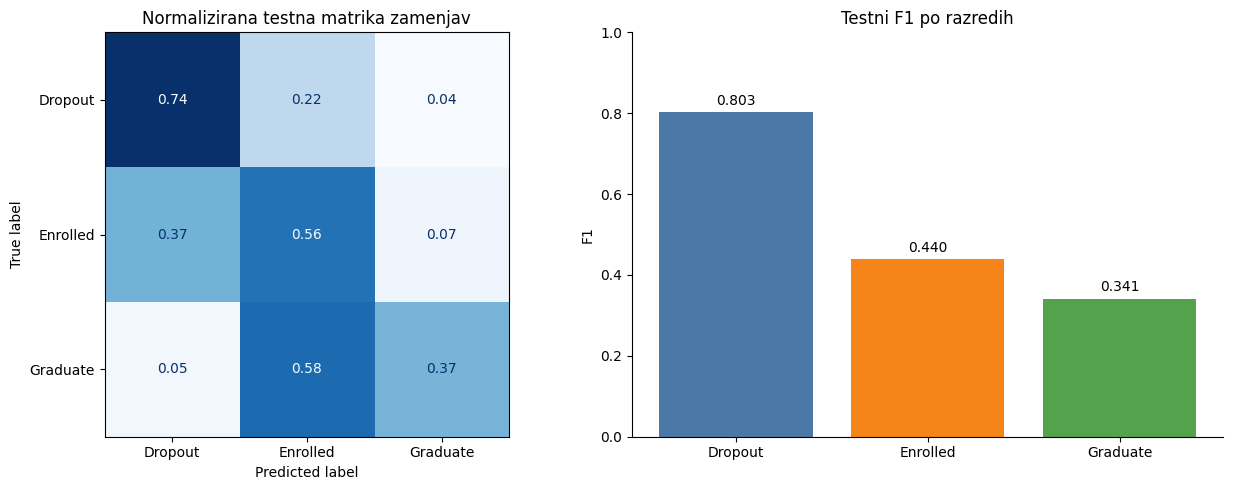

In [8]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
)

test_predictions = FINALIST_PIPELINE.predict(X_test)
test_accuracy = accuracy_score(y_test, test_predictions)
test_balanced_accuracy = balanced_accuracy_score(y_test, test_predictions)
test_macro_f1 = f1_score(
    y_test, test_predictions, labels=CLASS_ORDER, average="macro", zero_division=0
)
test_report = classification_report(
    y_test, test_predictions, labels=CLASS_ORDER, output_dict=True, zero_division=0
)
test_confusion = confusion_matrix(y_test, test_predictions, labels=CLASS_ORDER)
test_confusion_normalized = confusion_matrix(
    y_test, test_predictions, labels=CLASS_ORDER, normalize="true"
)

test_summary = pd.DataFrame({
    "Metrika": ["Accuracy", "Balanced accuracy", "Macro-F1"],
    "Vrednost": [test_accuracy, test_balanced_accuracy, test_macro_f1],
})
display(test_summary.style.format({"Vrednost": "{:.3f}"}))

test_class_report = pd.DataFrame([
    {
        "Razred": target_class,
        "Precision": test_report[target_class]["precision"],
        "Recall": test_report[target_class]["recall"],
        "F1": test_report[target_class]["f1-score"],
        "Support": int(test_report[target_class]["support"]),
    }
    for target_class in CLASS_ORDER
])
display(test_class_report.style.format({
    "Precision": "{:.3f}", "Recall": "{:.3f}", "F1": "{:.3f}",
}))
display(pd.DataFrame(
    test_confusion,
    index=[f"Dejanski {label}" for label in CLASS_ORDER],
    columns=[f"Napovedani {label}" for label in CLASS_ORDER],
))

BOOTSTRAP_REPEATS = 5000
bootstrap_rng = np.random.default_rng(RANDOM_STATE)
y_test_array = np.asarray(y_test)
test_predictions_array = np.asarray(test_predictions)
bootstrap_macro_f1 = np.empty(BOOTSTRAP_REPEATS)
for repeat in range(BOOTSTRAP_REPEATS):
    sample_indices = bootstrap_rng.integers(0, len(y_test_array), size=len(y_test_array))
    bootstrap_macro_f1[repeat] = f1_score(
        y_test_array[sample_indices], test_predictions_array[sample_indices],
        labels=CLASS_ORDER, average="macro", zero_division=0,
    )
bootstrap_ci_low, bootstrap_ci_high = np.quantile(bootstrap_macro_f1, [0.025, 0.975])
print(f"Testni macro-F1={test_macro_f1:.3f}; 95-% bootstrap interval=[{bootstrap_ci_low:.3f}, {bootstrap_ci_high:.3f}]")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay(
    confusion_matrix=test_confusion_normalized, display_labels=CLASS_ORDER
).plot(ax=axes[0], cmap="Blues", values_format=".2f", colorbar=False)
axes[0].set_title("Normalizirana testna matrika zamenjav")

class_f1_values = [test_report[label]["f1-score"] for label in CLASS_ORDER]
bars = axes[1].bar(CLASS_ORDER, class_f1_values, color=["#4C78A8", "#F58518", "#54A24B"])
axes[1].bar_label(bars, labels=[f"{value:.3f}" for value in class_f1_values], padding=3)
axes[1].set(title="Testni F1 po razredih", ylabel="F1", ylim=(0, 1))
axes[1].spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 4.7 Post-hoc razlaga

Po zaklenitvi modela izračunamo permutacijsko pomembnost izvornih 51 značilk na testu. Rezultat ne vpliva na izbor in ga ne razlagamo vzročno.

,Stolpec,Povprečni padec macro-F1,SD
0,Curricular units 1st sem (approved),0.0707,0.0300
1,Curricular units 2nd sem (approved),0.0492,0.0240
2,Tuition fees up to date,0.0314,0.0172
3,Age at enrollment,0.0242,0.0185
4,Curricular units 2nd sem (grade),0.0169,0.0239
5,Curricular units 1st sem (credited),0.0140,0.0051
6,Previous qualification (grade),0.0136,0.0119
7,Curricular units 1st sem (evaluations),0.0125,0.0164
8,Curricular units 2nd sem (evaluations),0.0102,0.0103
9,Logical reasoning test score,0.0102,0.0132


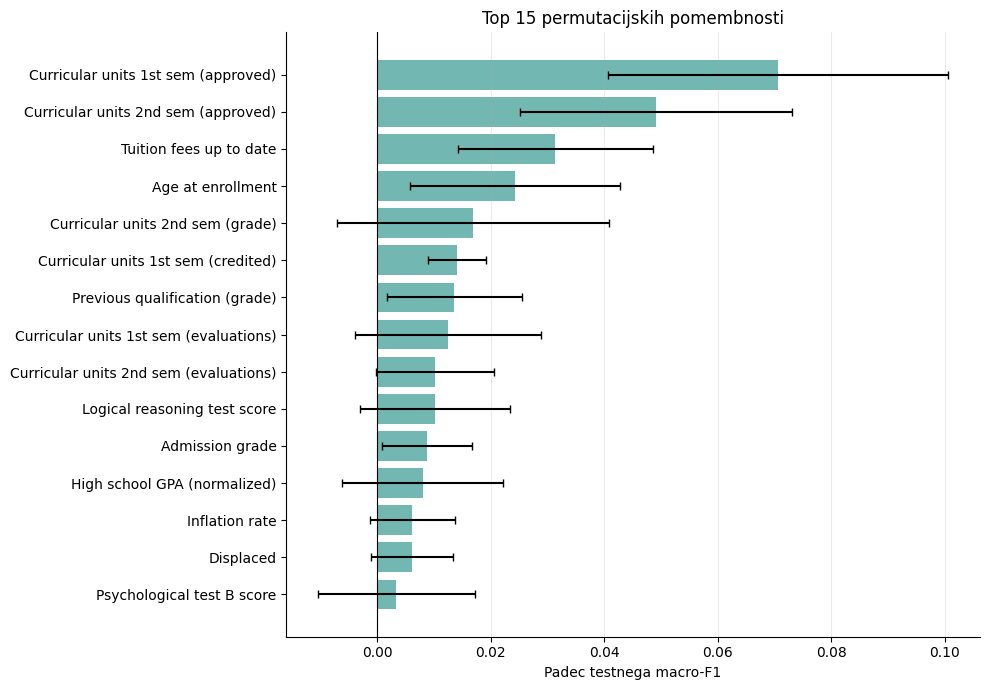

In [9]:
from sklearn.inspection import permutation_importance

permutation_result = permutation_importance(
    FINALIST_PIPELINE,
    X_test,
    y_test,
    scoring="f1_macro",
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=1,
)
importance_summary = pd.DataFrame({
    "Stolpec": X_test.columns,
    "Povprečni padec macro-F1": permutation_result.importances_mean,
    "SD": permutation_result.importances_std,
}).sort_values("Povprečni padec macro-F1", ascending=False, ignore_index=True)
top_importance = importance_summary.head(15).copy()
display(top_importance.style.format({
    "Povprečni padec macro-F1": "{:.4f}", "SD": "{:.4f}",
}))

plot_importance = top_importance.sort_values("Povprečni padec macro-F1")
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(
    plot_importance["Stolpec"], plot_importance["Povprečni padec macro-F1"],
    xerr=plot_importance["SD"], color="#72B7B2", capsize=3,
)
ax.axvline(0, color="black", linewidth=0.8)
ax.set(title="Top 15 permutacijskih pomembnosti", xlabel="Padec testnega macro-F1", ylabel="")
ax.grid(axis="x", alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 4.8 Sklep in omejitve

Finalist je uglašeni **HistGradientBoosting T02**. Njegove selekcijske CV-ocene so macro-F1 **0,558 ± 0,011**, balanced accuracy **0,635**, Graduate F1 **0,342** in Graduate recall **0,547**.

- Zaklenjeni test: **macro-F1 0,528**, 95-% bootstrap interval **[0,451, 0,601]**, balanced accuracy 0,556.
- F1 po razredih: `Dropout` 0,803, `Enrolled` 0,440, `Graduate` 0,341. Model pravilno prepozna 7 od 19 primerov `Graduate`.
- Zgodnja različica doseže CV macro-F1 0,408 ± 0,007, zato je končni model namenjen napovedi po 2. semestru in ni zgodnji opozorilni sistem.
- Dodatek ID-stolpcev doseže 0,570 ± 0,028, vendar poveča raztros in tveganje naključne povezave oziroma uhajanja; zato ID-stolpci ostanejo izločeni.
- Najpomembnejše permutacijske značilke so odobrene učne enote v 1. in 2. semestru, poravnane šolnine in starost ob vpisu. Pomembnosti niso dokaz vzročnosti.

Glavne omejitve so samo 19 testnih primerov `Graduate`, 7,87 % manjkajočih napovednih vrednosti, odsotnost uradnega šifranta redkih kategorij, nejasen čas merjenja nekaterih dodatnih spremenljivk in odsotnost zunanje validacije. Vsi slabši, neuravnoteženi, SMOTENC, uglašeni in ablacijski poskusi so ohranjeni v eni sledilni preglednici. Test ni vplival na izbor modela ali hiperparametrov.